In [1]:
from keras.layers import Dense,Dropout, BatchNormalization,Flatten
from keras.models import load_model,save_model
from keras.models import Model
from keras.applications.vgg19 import VGG19
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
train_path = 'C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/train'
valid_path = 'C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/test'

In [3]:
# load model without output layer

IMAGE_SIZE = [224, 224]
# add preprocessing layer to the front of VGG
vgg = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [4]:
# don't train existing weights
for layer in vgg.layers:
    layer.trainable = False

In [5]:
# useful for getting number of classes
folders = glob('C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/train/*')

In [6]:
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

In [7]:
# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

In [8]:
# view the structure of the model
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [9]:
# tell the model what cost and optimization method to use
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [10]:
from keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

val_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

val_set = val_datagen.flow_from_directory('C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

# fit the model
history = model.fit_generator(training_set,
                              validation_data=val_set,
                              epochs=20,
                              steps_per_epoch=len(training_set),
                              validation_steps=len(val_set))


Found 770 images belonging to 4 classes.
Found 770 images belonging to 4 classes.


C:\Users\vishw\AppData\Local\Temp\ipykernel_11756\4170597925.py:20: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(training_set,


Epoch 1/20
25/25 [==============================] - 226s 9s/step - loss: 1.7171 - accuracy: 0.5143 - val_loss: 0.8195 - val_accuracy: 0.6974
Epoch 2/20
25/25 [==============================] - 230s 9s/step - loss: 0.7825 - accuracy: 0.7195 - val_loss: 0.5659 - val_accuracy: 0.7818
Epoch 3/20
25/25 [==============================] - 221s 9s/step - loss: 0.5942 - accuracy: 0.7766 - val_loss: 0.4304 - val_accuracy: 0.8506
Epoch 4/20
25/25 [==============================] - 216s 9s/step - loss: 0.5150 - accuracy: 0.8208 - val_loss: 0.6133 - val_accuracy: 0.7961
Epoch 5/20
25/25 [==============================] - 209s 9s/step - loss: 0.5219 - accuracy: 0.7948 - val_loss: 0.4168 - val_accuracy: 0.8325
Epoch 6/20
25/25 [==============================] - 217s 9s/step - loss: 0.5009 - accuracy: 0.8130 - val_loss: 0.3870 - val_accuracy: 0.8455
Epoch 7/20
25/25 [==============================] - 226s 9s/step - loss: 0.3631 - accuracy: 0.8649 - val_loss: 0.3310 - val_accuracy: 0.8805
Epoch 8/20
25

        loss  accuracy  val_loss  val_accuracy
0   1.717131  0.514286  0.819475      0.697403
1   0.782524  0.719481  0.565920      0.781818
2   0.594209  0.776623  0.430431      0.850649
3   0.515023  0.820779  0.613290      0.796104
4   0.521880  0.794805  0.416767      0.832468
5   0.500944  0.812987  0.387047      0.845455
6   0.363096  0.864935  0.331048      0.880520
7   0.362389  0.861039  0.255433      0.905195
8   0.346178  0.871429  0.214429      0.940260
9   0.254293  0.911688  0.206598      0.924675
10  0.235560  0.920779  0.176887      0.932468
11  0.201778  0.937662  0.148035      0.958442
12  0.208487  0.929870  0.132488      0.972727
13  0.177515  0.946753  0.133763      0.964935
14  0.164318  0.950649  0.131307      0.949351
15  0.165816  0.942857  0.114332      0.963636
16  0.178550  0.937662  0.114042      0.961039
17  0.140915  0.961039  0.120816      0.961039
18  0.140319  0.961039  0.100670      0.975325
19  0.170784  0.942857  0.099076      0.976623


<Axes: >

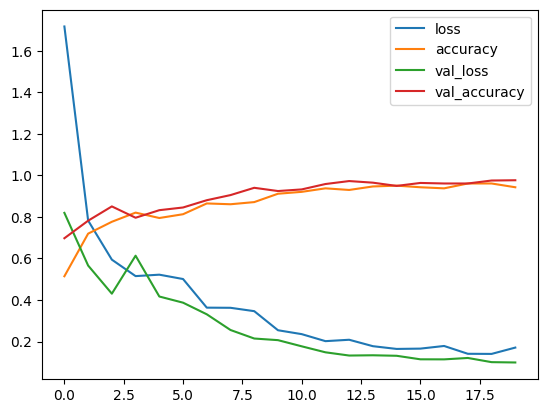

In [11]:
from keras.models import load_model

model.save('model.h5')


print(pd.DataFrame(history.history))

pd.DataFrame(history.history).plot()

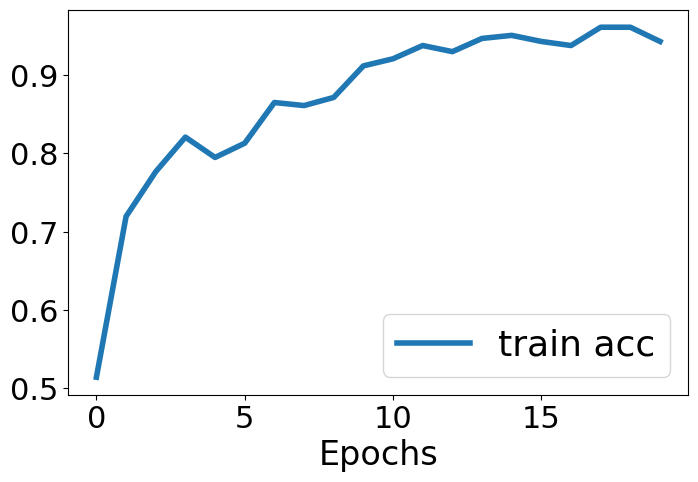

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots( figsize = (8,5))
ax.plot(history.history['accuracy'], label= 'train acc', linewidth = 4)
ax.legend(fontsize = 26)
ax.tick_params(labelsize=22)
ax.set_xlabel('Epochs', fontsize = 24)


plt.show()


In [13]:
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [14]:
test_path = 'C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/test/'#test icin kullanilacak fotograflar

In [15]:
import itertools

def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_path,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False)


class_labels = test_generator.class_indices
class_labels = {v: k for k, v in class_labels.items()}
classes = list(class_labels.values())


nb_validation_samples = 1435
batch_size = 5
#Confution Matrix and Classification Report
Y_pred = model.predict_generator(test_generator, nb_validation_samples // batch_size+1)
y_pred = np.argmax(Y_pred, axis=1)

print('Confusion Matrix')
print(confusion_matrix(test_generator.classes, y_pred))
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

Found 770 images belonging to 4 classes.


C:\Users\vishw\AppData\Local\Temp\ipykernel_11756\3460943704.py:18: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(test_generator, nb_validation_samples // batch_size+1)


Confusion Matrix
[[ 99   1   6   1]
 [  0  90   1   0]
 [  2   3 274   0]
 [  0   4   0 289]]
Classification Report
              precision    recall  f1-score   support

  Chickenpox       0.98      0.93      0.95       107
     Measles       0.92      0.99      0.95        91
   Monkeypox       0.98      0.98      0.98       279
      Normal       1.00      0.99      0.99       293

    accuracy                           0.98       770
   macro avg       0.97      0.97      0.97       770
weighted avg       0.98      0.98      0.98       770



In [17]:
import itertools

def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [18]:
cm = confusion_matrix(test_generator.classes, y_pred)
np.set_printoptions(precision=2)

[[ 99   1   6   1]
 [  0  90   1   0]
 [  2   3 274   0]
 [  0   4   0 289]]


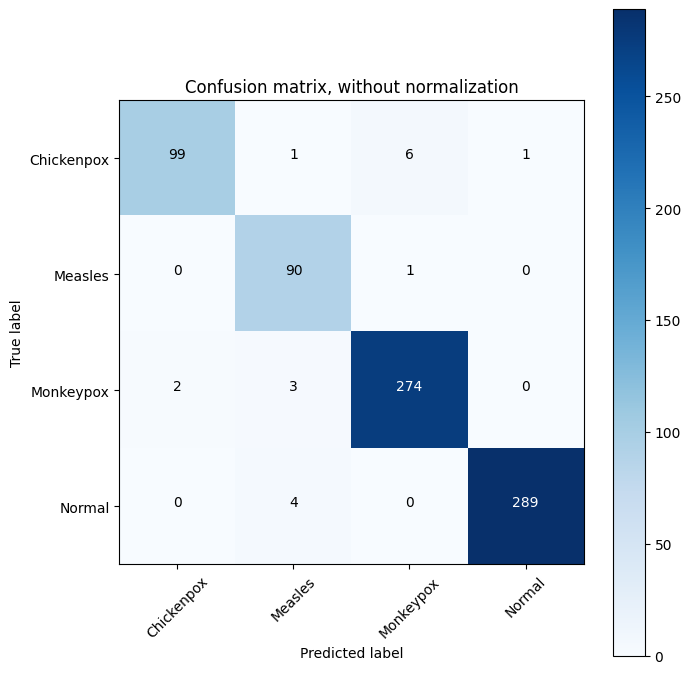

In [19]:
plt.figure(figsize=(7,7))
plot_confusion_matrix(cm, classes=target_names,
                      title='Confusion matrix, without normalization')

In [20]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('model.h5')

In [21]:
import numpy as np
from tensorflow.keras.preprocessing import image

def preprocess_image(image_path):
    # Load the image
    img = image.load_img(image_path, target_size=(224, 224))
    
    # Convert the image to an array
    img_array = image.img_to_array(img)
    
    # Expand dimensions to match the shape required by the model
    img_array = np.expand_dims(img_array, axis=0)
    
    # Normalize the image
    img_array /= 255.0
    
    return img_array


In [22]:
# Path to the image you want to test
image_path = 'C:/Users/vishw/OneDrive/Desktop/monkeypox/datasets/test/Chickenpox/chickenpox1.png'

# Preprocess the image
img_array = preprocess_image(image_path)

# Make a prediction
predictions = model.predict(img_array)

# Decode the prediction
predicted_class_index = np.argmax(predictions[0])
class_labels = {v: k for k, v in training_set.class_indices.items()}

print(f'Predicted class: {class_labels[predicted_class_index]}')


1/1 [==============================] - 0s 321ms/step
Predicted class: Chickenpox
